## Libraries
This section imports all the necessary libraries for clustering analysis and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import seaborn as sns

## Import the dataset
Load the data to be used for clustering. The file should contain the features for clustering analysis.

In [ ]:
data = pd.read_csv('/content/res.csv')
data.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.957245,-0.657963,0.603670,-1.353815,-1.170867,-0.610053,0.245194,0.247645,1.687027
1,-1.104562,-0.338353,-0.726376,-1.467695,-1.053931,0.050732,-0.162231,0.165876,1.639917
2,-0.832065,-0.722856,1.491691,-1.156462,-1.350077,0.188561,0.557361,0.031295,1.465240
3,-0.924352,-0.630474,0.876506,-1.252128,-1.346315,0.081255,0.283706,0.169198,1.496466
4,-1.101101,-0.362978,-0.646041,-1.464433,-1.085266,-0.017768,-0.161298,0.204133,1.638680


## KMeans Clustering
Apply the KMeans algorithm to group similar data points into clusters.

### Optimal number of clusters
Use the elbow method and silhouette analysis to determine the best number of clusters for KMeans.
here we chose k=4 based on the elbow method and silhouette analysis

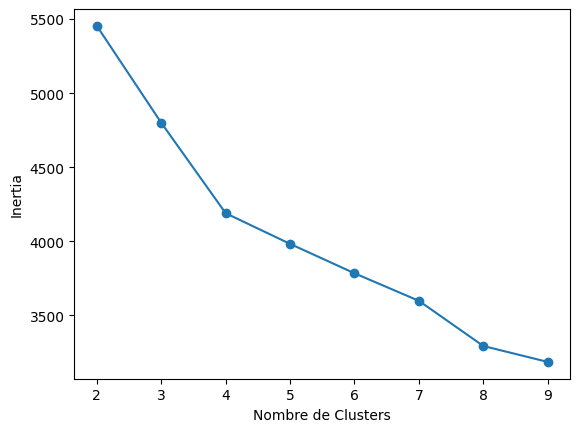

In [ ]:
#elbow method
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Nombre de Clusters')
plt.ylabel('Inertia')
plt.show()

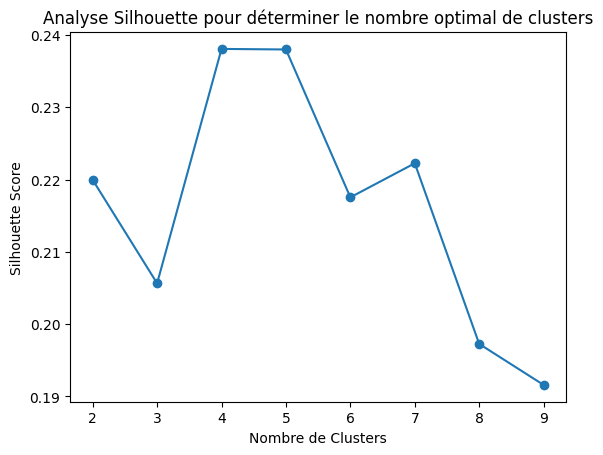

In [ ]:
#silhouette analysis method
silhouette_scores = []
range_n_clusters = range(2, 10)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data)
    score = silhouette_score(data, labels)
    silhouette_scores.append(score)

# Visualisation des scores
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Nombre de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Analyse Silhouette pour déterminer le nombre optimal de clusters')
plt.show()

### Clustering and Visualization
Fit the KMeans model and visualize the resulting clusters in 2D and 3D.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(data)
data['Cluster'] = labels


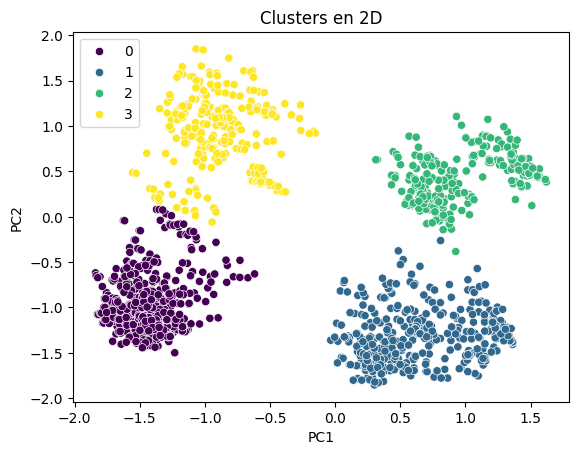

In [ ]:
sns.scatterplot(x=data.iloc[:, 0], y=data.iloc[:, 1], hue=labels, palette='viridis')
plt.title('Clusters en 2D')
plt.show()

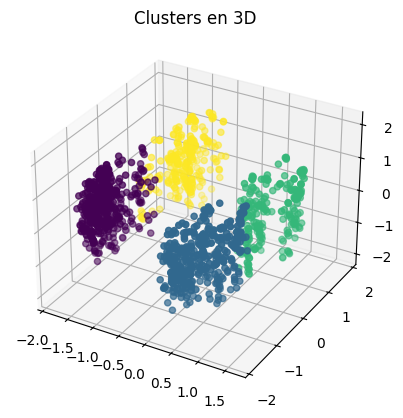

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['PC1'], data['PC2'], data['PC3'], c=labels, cmap='viridis')
plt.title('Clusters en 3D')
plt.show()

### Cluster Interpretation
Analyze the characteristics of each cluster to understand the patterns in the data.

In [ ]:
#ajout du label cluster
original_data = pd.read_csv('/content/original_data (3).csv')
original_data['Cluster'] = labels

# Rename columns
original_data.rename(columns={
    'los_unit_clean': 'los_unit',
    'los_total_clean': 'los_total',
}, inplace=True)

original_data.to_csv('clustered_data.csv', index=False)
clustered_data = pd.read_csv('clustered_data.csv')

<ipython-input-119-b1bf4a9841dc>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x='Cluster', data=data, palette=pal)


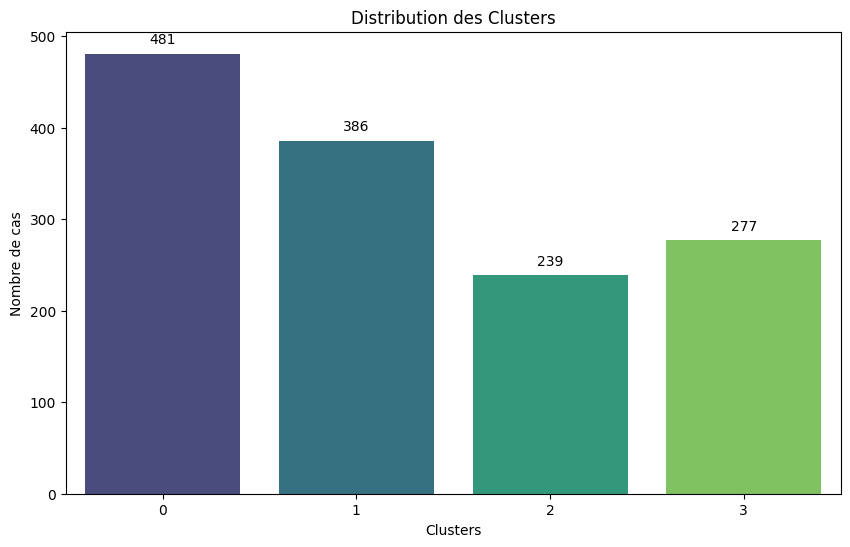

In [ ]:
pal = sns.color_palette("viridis", len(data['Cluster'].unique()))

# Créer le countplot
plt.figure(figsize=(10, 6))
pl = sns.countplot(x='Cluster', data=data, palette=pal)

# Ajouter des étiquettes de valeur sur les barres
for p in pl.patches:
    pl.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 fontsize=10, color='black',
                 xytext=(0, 5),
                 textcoords='offset points')

# Titre et labels
pl.set_title("Distribution des Clusters")
pl.set_xlabel("Clusters")
pl.set_ylabel("Nombre de cas")

# Afficher le graphique
plt.show()

In [ ]:
# Répartition des catégories pour chaque variable catégorique par cluster
categorical_cols = ['discharge_location', 'admission_type', 'admission_location',
                    'insurance','race', 'marital_status', 'gender','eventtype','death_status','careunit','curr_service']

for col in categorical_cols:
    print(f"Distribution de {col} par cluster :")
    print(original_data.groupby('Cluster')[col].value_counts(normalize=True))
    print("\n")


Distribution de discharge_location par cluster :
Cluster  discharge_location          
0        HOME HEALTH CARE                0.507277
         SKILLED NURSING FACILITY        0.158004
         HOME                            0.139293
         REHAB                           0.093555
         AGAINST ADVICE                  0.056133
         DIED                            0.045738
1        HOME HEALTH CARE                0.510363
         HOME                            0.227979
         REHAB                           0.080311
         SKILLED NURSING FACILITY        0.077720
         CHRONIC/LONG TERM ACUTE CARE    0.064767
         DIED                            0.020725
         ACUTE HOSPITAL                  0.010363
         AGAINST ADVICE                  0.007772
2        HOME HEALTH CARE                0.271967
         HOME                            0.251046
         SKILLED NURSING FACILITY        0.146444
         HOSPICE                         0.108787
         DIED

In [ ]:
#les valeurs numériques
numerical_cols = ['anchor_age', 'los_unit', 'los_total']

# Calculer les moyennes, médianes, etc., pour chaque cluster
numerical_summary = original_data.groupby('Cluster')[numerical_cols].describe()
print(numerical_summary)


        anchor_age                                                      \
             count       mean        std   min   25%   50%   75%   max   
Cluster                                                                  
0            481.0  57.567568  11.740604  28.0  51.0  60.0  64.0  87.0   
1            386.0  59.753886  20.213254  21.0  46.0  63.0  78.0  91.0   
2            239.0  60.841004  12.136818  38.0  48.0  64.0  67.0  91.0   
3            277.0  67.707581  12.971724  51.0  57.0  65.0  84.0  91.0   

        los_unit             ...                        los_total              \
           count       mean  ...        75%         max     count        mean   
Cluster                      ...                                                
0          481.0  31.449872  ...  47.273333  131.005556     481.0  182.421073   
1          386.0  29.627479  ...  47.421597  131.005556     386.0  166.759886   
2          239.0  36.287032  ...  54.763056  131.005556     239.0  227.06174

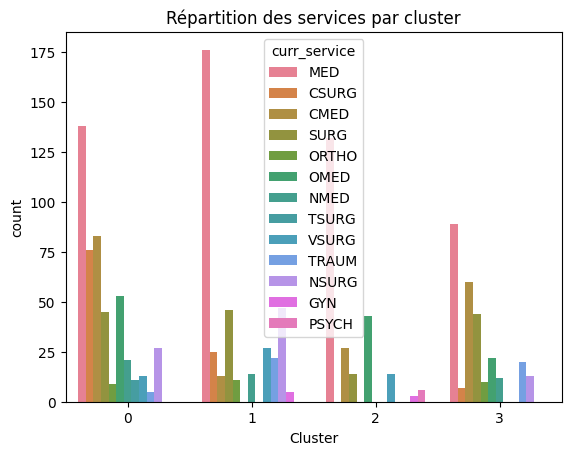

In [ ]:
sns.countplot(x='Cluster', hue='curr_service', data=clustered_data)
plt.title('Répartition des services par cluster')
plt.show()

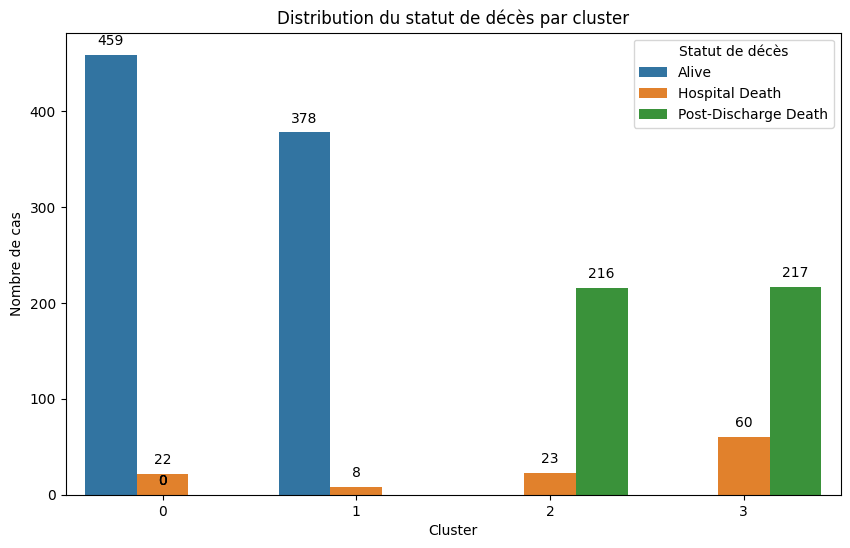

In [ ]:
# Créer le graphique à barres
plt.figure(figsize=(10, 6))
death_status_counts = original_data.groupby(['Cluster', 'death_status'])['death_status'].count().reset_index(name='Count')

bar_plot = sns.barplot(data=death_status_counts, x='Cluster', y='Count', hue='death_status')

# Ajouter des étiquettes de valeur sur les barres
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom',
                      fontsize=10, color='black',
                      xytext=(0, 5),
                      textcoords='offset points')

plt.title('Distribution du statut de décès par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de cas')
plt.legend(title='Statut de décès')
plt.show()

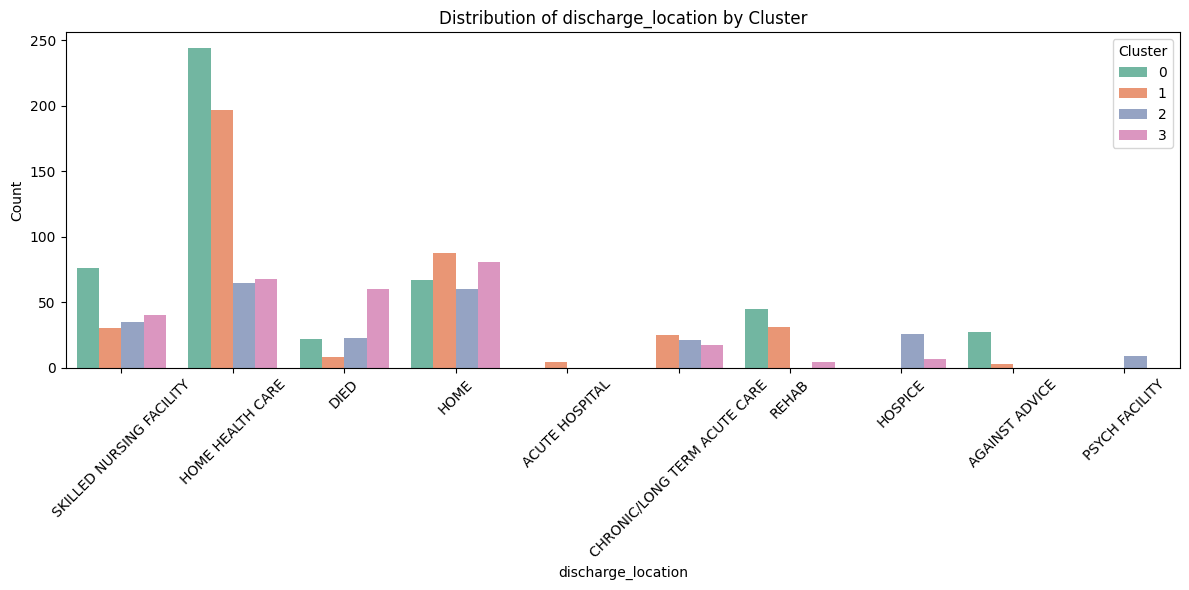

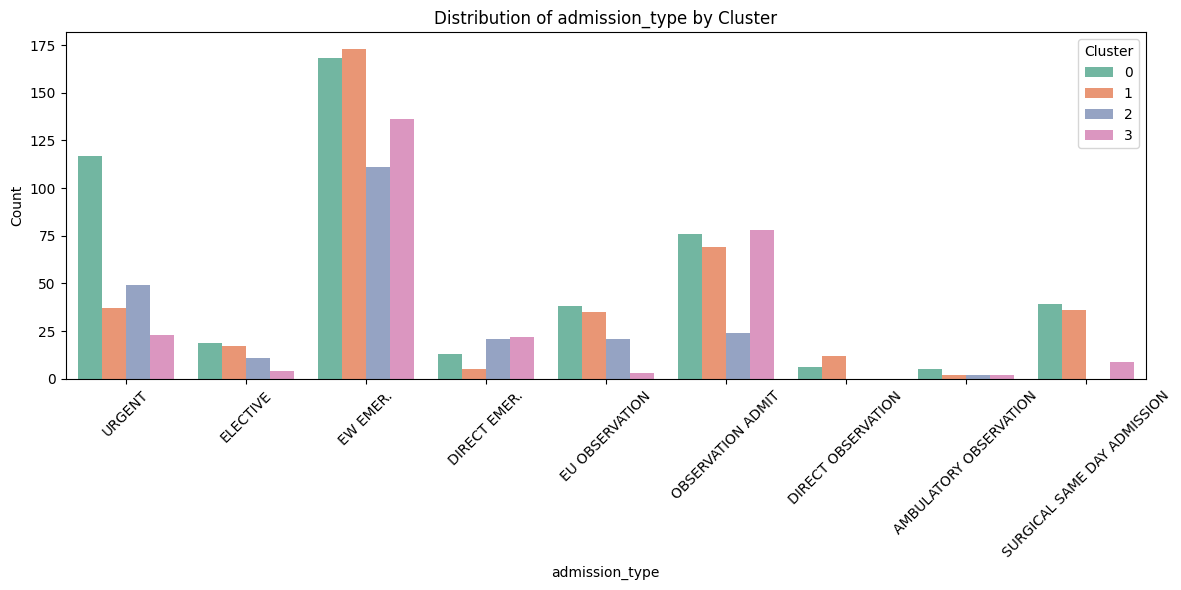

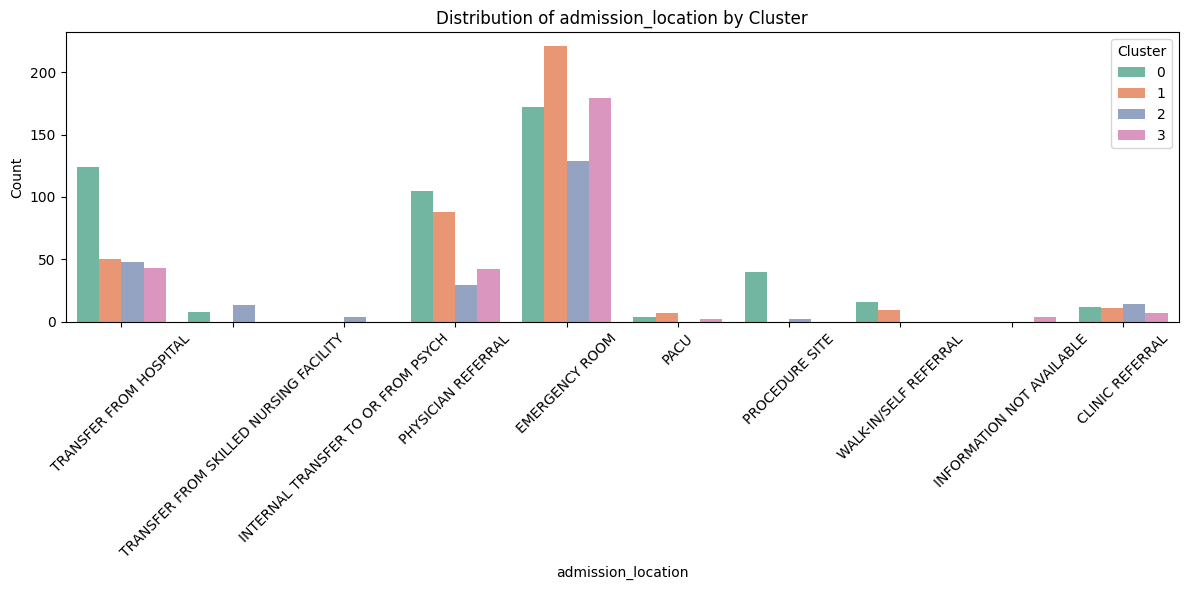

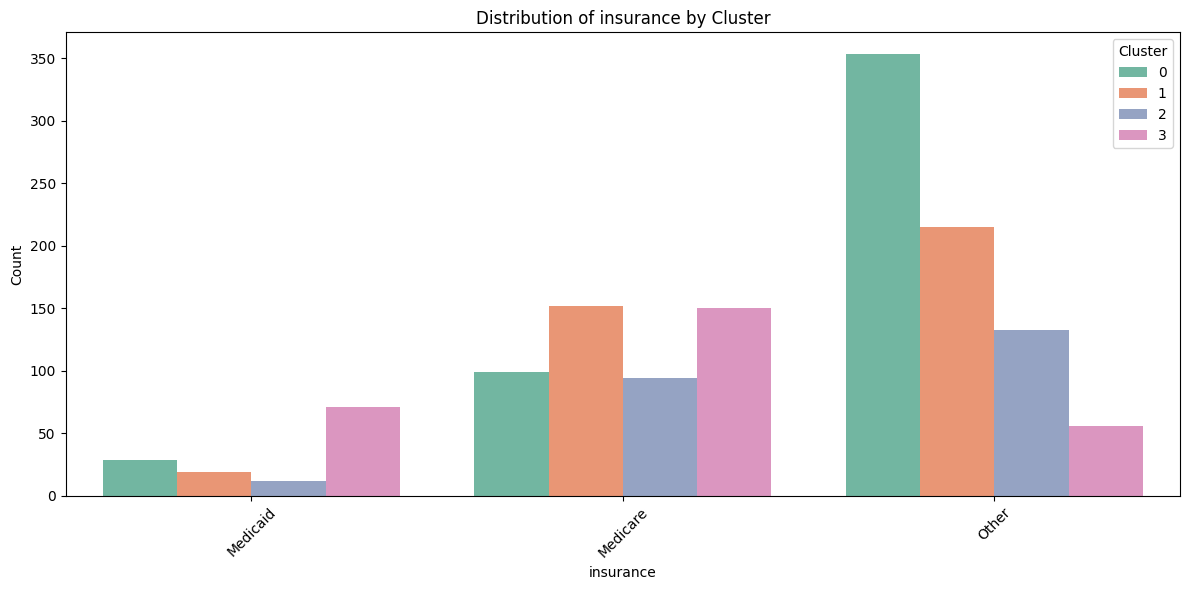

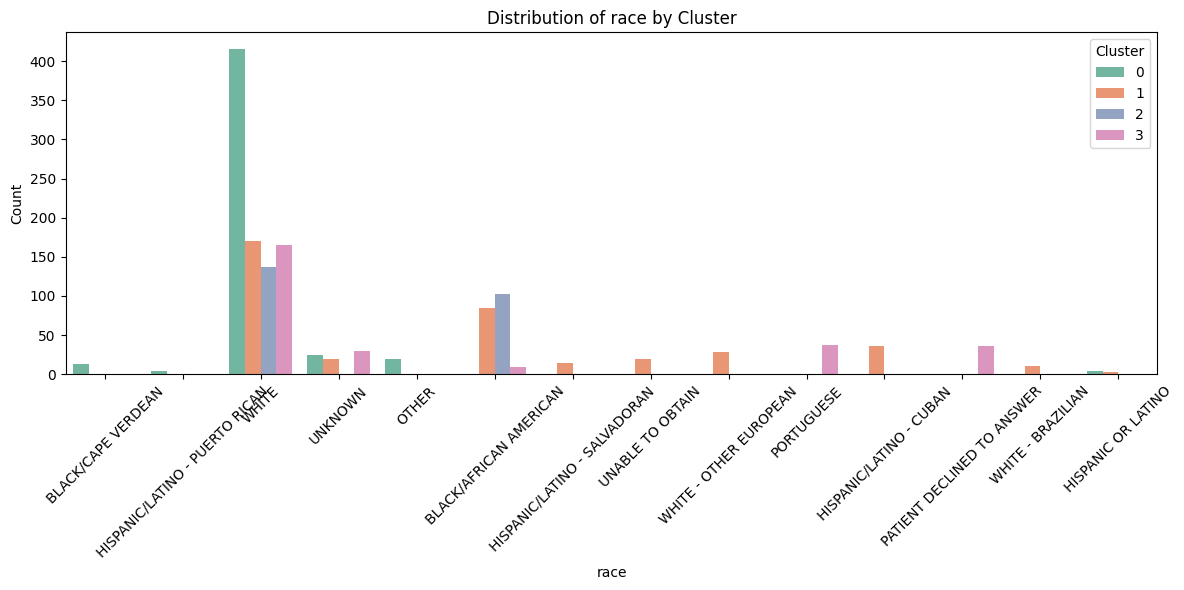

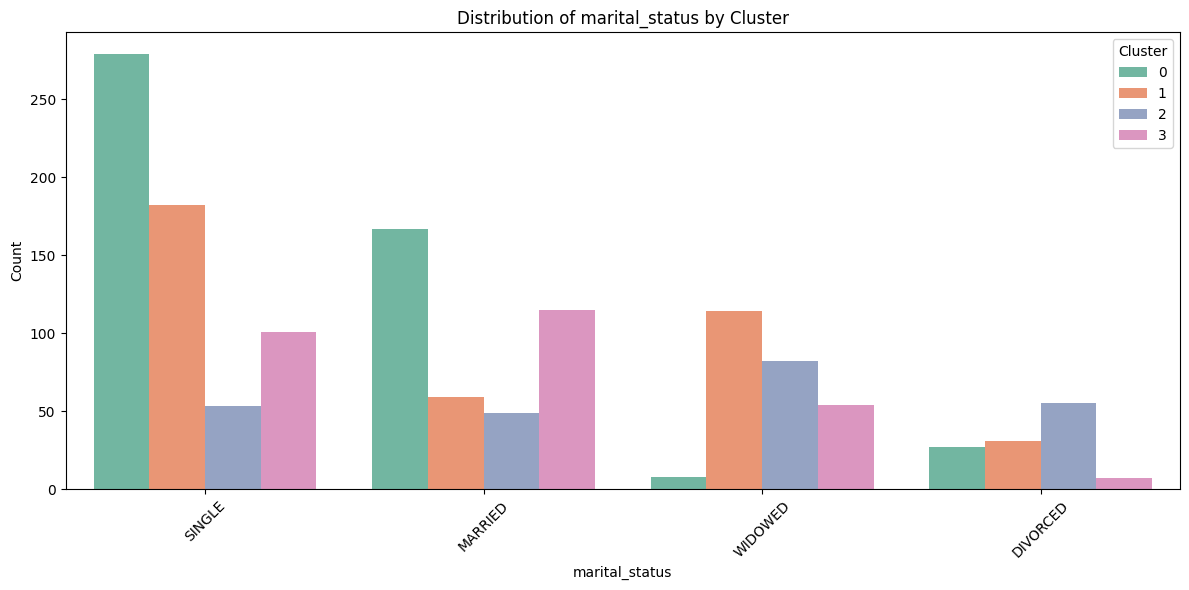

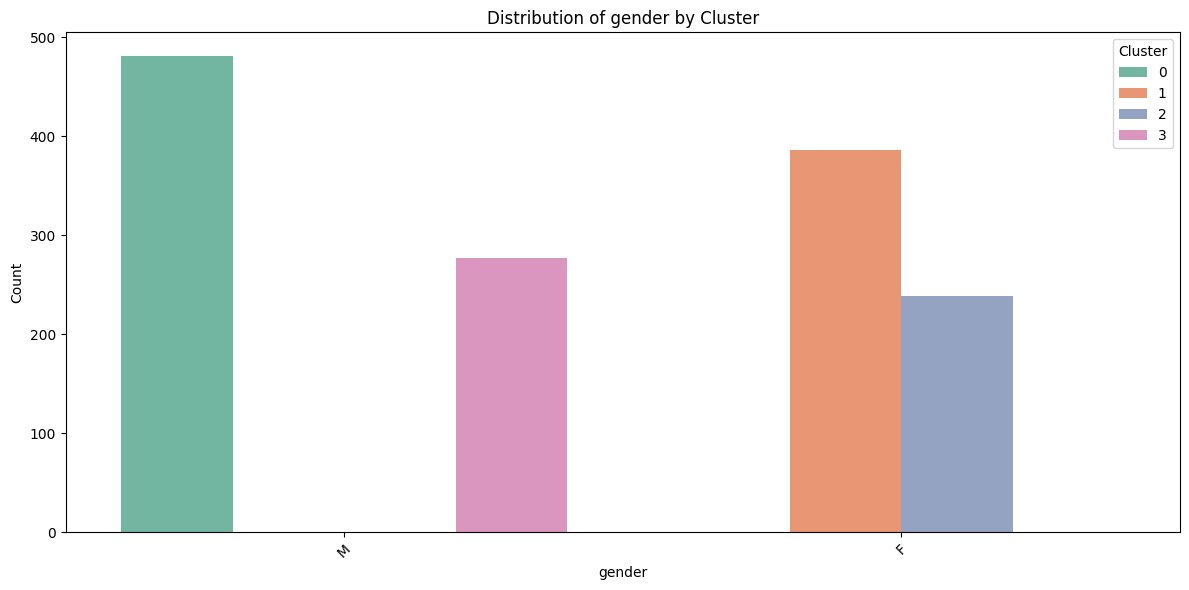

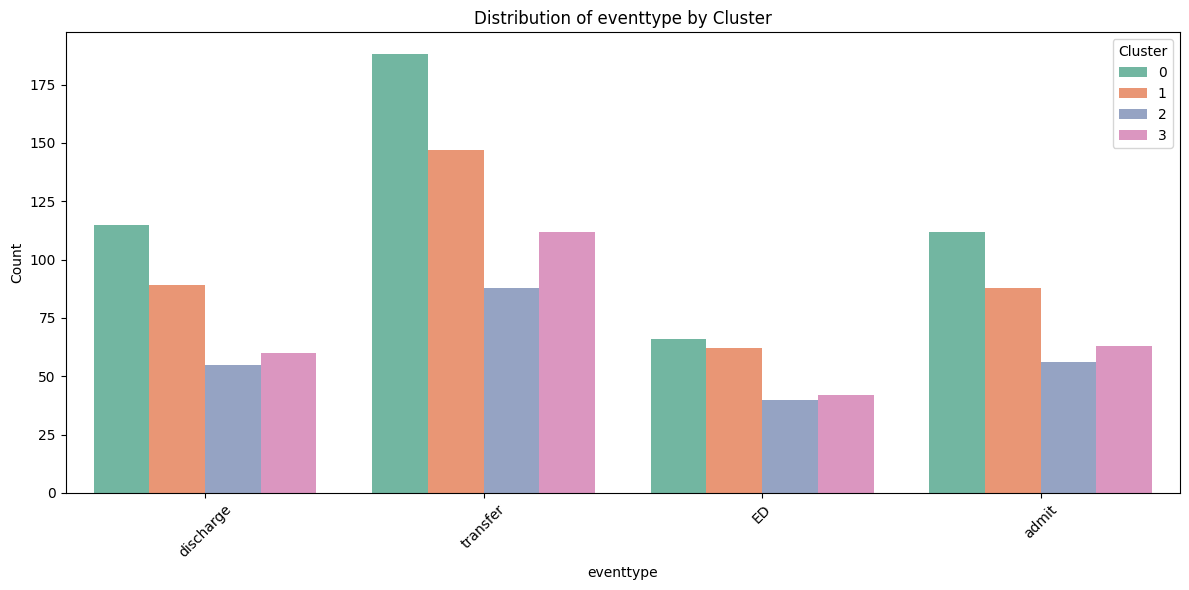

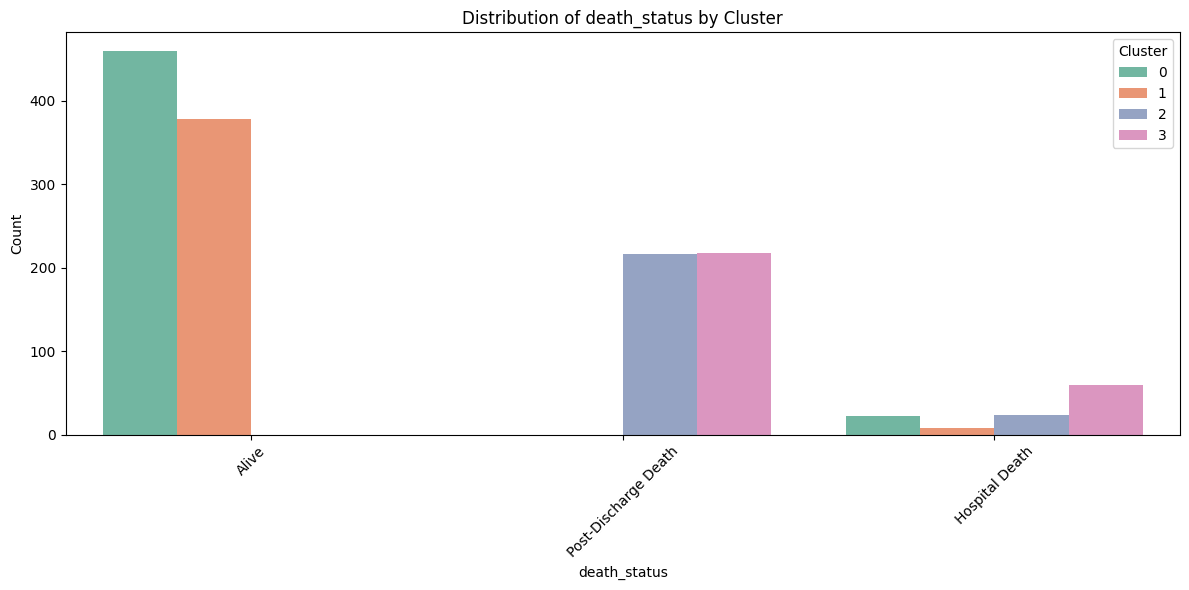

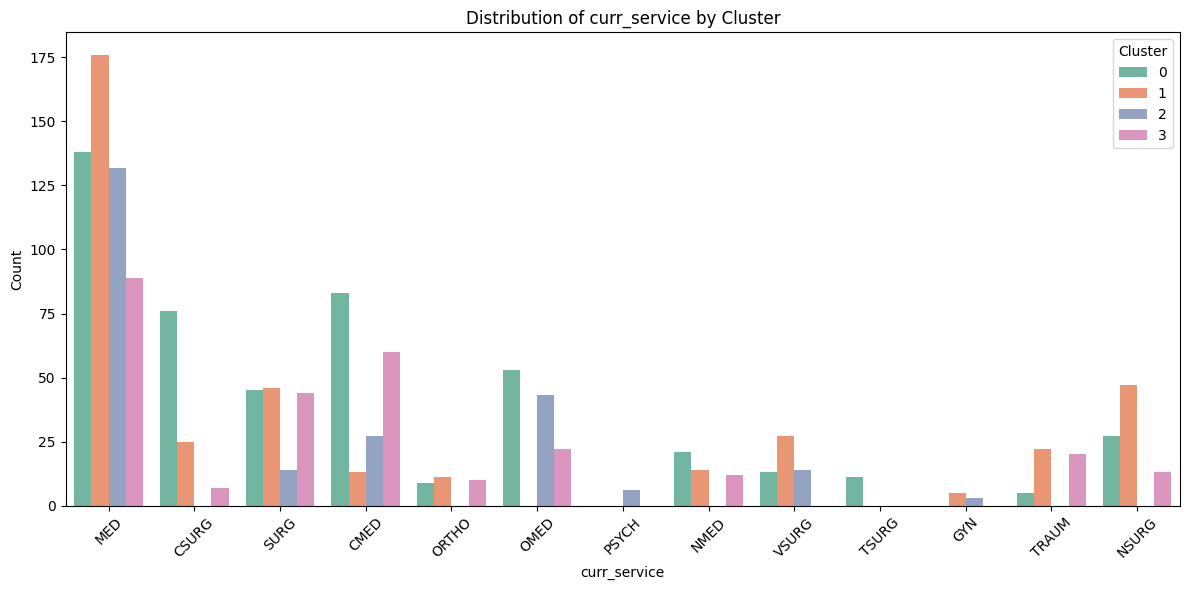

<ipython-input-124-ade8ff38787e>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Cluster', y=feature, palette='Set2')


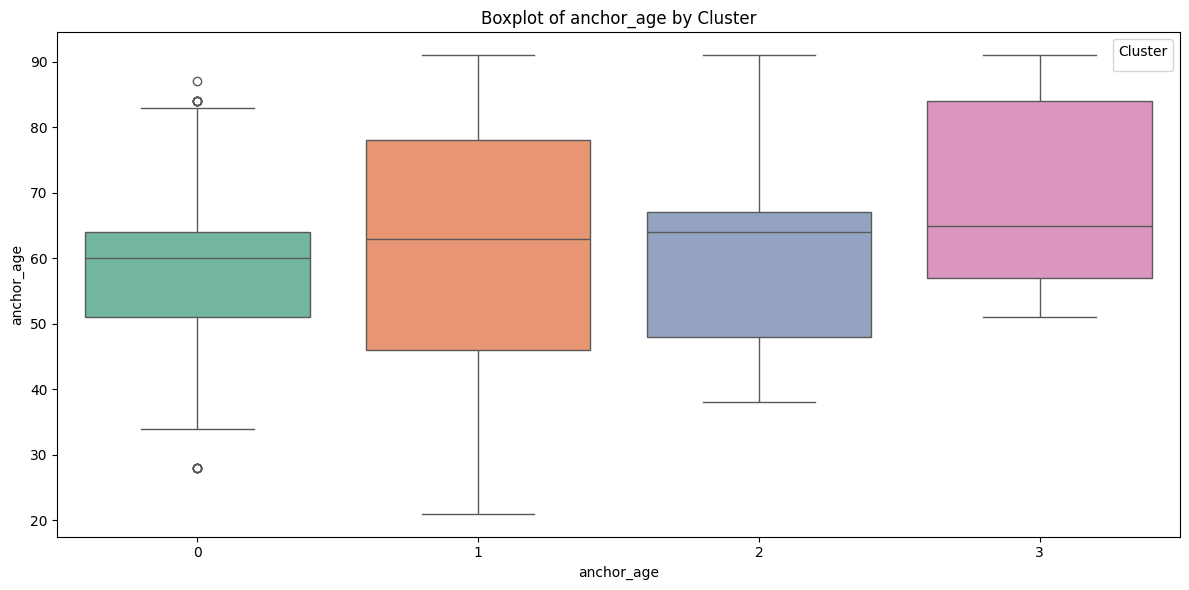

<ipython-input-124-ade8ff38787e>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Cluster', y=feature, palette='Set2')


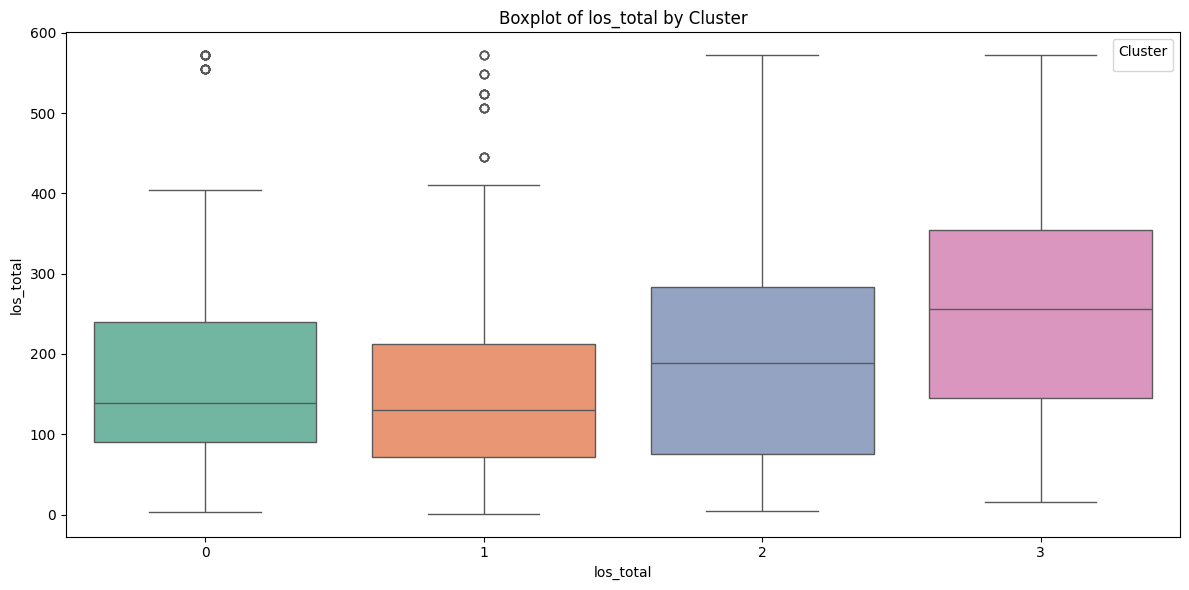

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
data = pd.read_csv('/content/clustered_data.csv')

# Ajouter une colonne pour les clusters (remplacez 'cluster_column' par le nom de votre colonne de cluster)
# data['Cluster'] = ... # Assurez-vous d'avoir une colonne qui indique le cluster de chaque ligne

# Liste des caractéristiques à visualiser
features = [
    'discharge_location', 'admission_type', 'admission_location',
    'insurance', 'race', 'marital_status',
    'gender', 'eventtype', 'death_status', 'curr_service',
    'anchor_age', 'los_total'
]

# Visualisation de chaque caractéristique
for feature in features:
    plt.figure(figsize=(12, 6))

    # Si la caractéristique est catégorique
    if data[feature].dtype == 'object':
        sns.countplot(data=data, x=feature, hue='Cluster', palette='Set2')
        plt.title(f'Distribution of {feature} by Cluster')
        plt.xticks(rotation=45)
    else:
        # Si la caractéristique est numérique
        sns.boxplot(data=data, x='Cluster', y=feature, palette='Set2')
        plt.title(f'Boxplot of {feature} by Cluster')

    plt.xlabel(feature)
    plt.ylabel('Count' if data[feature].dtype == 'object' else feature)
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

---
* ---Cluster 0: Male patients with less severe conditions (481 patients)
* a very low mortality rate (only 4.6%)
* individuals with less severe conditions, requiring care without complications
* non-urgent conditions
* only men
* younger patients
* dominated by whites
* shorter stays
* The majority have private insurance
* ---Cluster 1: Female patients with manageable medical needs (386 patients)
* Younger patients
* a very low mortality rate (only 2%)
* short stays
* only women
* dominated by whites
* majority have private insurance
* ---Cluster 2: Severely ill female patients (239 patients)
* only women
* 100% mortality rate
* majority widowed/divorced
* older patients
* longer stays
* black and African Americans
* public/private insurance
* ---Cluster 3: Critically ill male patients (277 patients)
* only men
* 100% mortality rate
* older patients
* longer stays
* more critical situations
* majority married
* majority have public insurance (Medicaid: insurance for low income)



**Notes:**
- Most patients (all clusters) are admitted via the emergency department. Improving this access route could optimize care.
- Most Black and African American patients are in cluster 2, reflecting inequalities in access.
- Clusters with high mortality rates (Clusters 2 and 3) require more targeted treatment protocols and prolonged intensive care.

## DBSCAN Clustering
Apply the DBSCAN algorithm to identify clusters of varying shapes and detect noise/outliers.

In [ ]:
data_copy = data.copy()
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_copy)

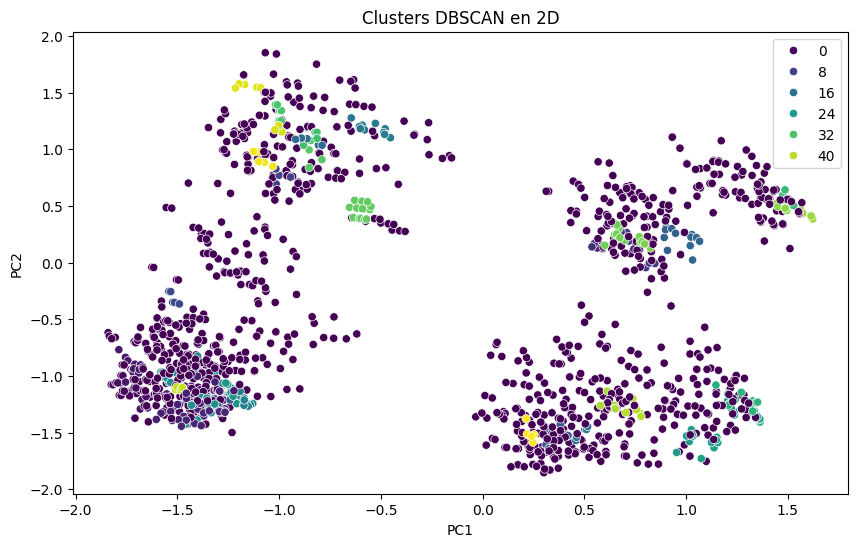

In [ ]:
data_copy['DBSCAN_Cluster'] = dbscan_labels

# Visualisation des clusters DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data.iloc[:, 0], y=data.iloc[:, 1], hue=dbscan_labels, palette='viridis')
plt.title('Clusters DBSCAN en 2D')
plt.show()

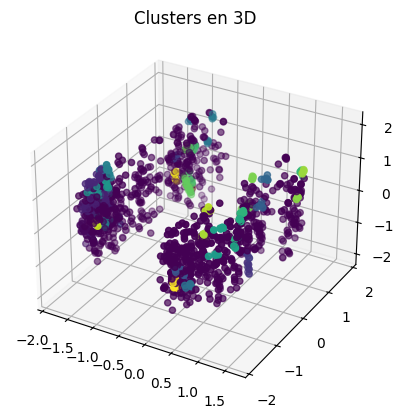

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['PC1'], data['PC2'], data['PC3'], c=dbscan_labels, cmap='viridis')
plt.title('Clusters en 3D')
plt.show()

## Hierarchical Clustering
Use Agglomerative Clustering to build a hierarchy of clusters and visualize the results.

In [ ]:
data_copy2 = data.copy()

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(data_copy2)


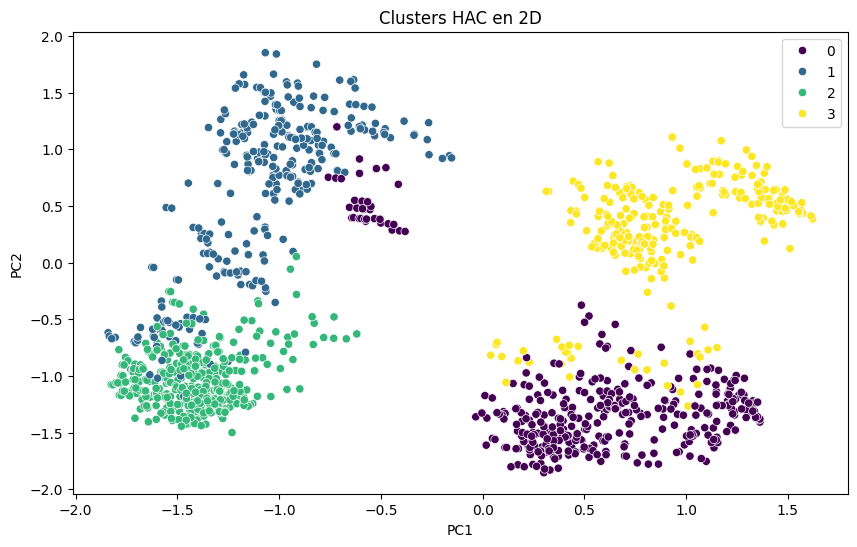

In [ ]:
# Visualisation des clusters HAC
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data.iloc[:, 0], y=data.iloc[:, 1], hue=agg_labels, palette='viridis', legend='full')
plt.title('Clusters HAC en 2D')
plt.show()

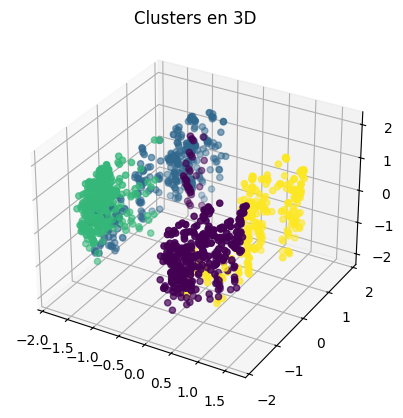

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['PC1'], data['PC2'], data['PC3'], c=agg_labels, cmap='viridis')
plt.title('Clusters en 3D')
plt.show()

## Gaussian Mixture Model (GMM)
Apply the GMM algorithm for probabilistic clustering, allowing for soft cluster assignments.

In [ ]:
data_copy1 = data.copy()

gmm = GaussianMixture(n_components=4)
gmm.fit(data_copy1)

GaussianMixture(n_components=4)

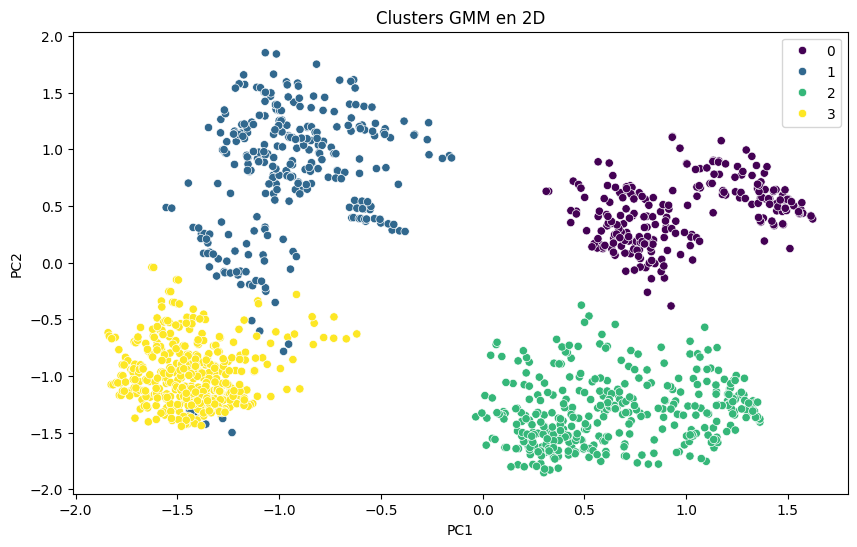

In [ ]:
# Predict the cluster labels using the fitted GMM model
gmm_labels = gmm.predict(data_copy1)

data_copy1['gmm'] = gmm_labels # Now use the correctly named gmm_labels

# Visualisation des clusters GMM
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data.iloc[:, 0], y=data.iloc[:, 1], hue=gmm_labels, palette='viridis', legend='full') # And here
plt.title('Clusters GMM en 2D')
plt.show()

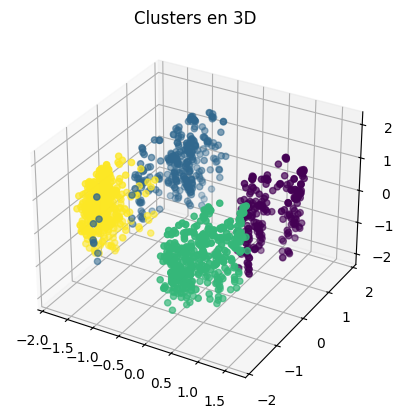

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['PC1'], data['PC2'], data['PC3'], c=gmm_labels, cmap='viridis')
plt.title('Clusters en 3D')
plt.show()

# Conclusion :
Kmeans algorithm gave us the best results overall
we grouped patients into 4 groups 
---
* ---Cluster 0: Male patients with less severe conditions (481 patients)
* a very low mortality rate (only 4.6%)
* individuals with less severe conditions, requiring care without complications
* non-urgent conditions
* only men
* younger patients
* dominated by whites
* shorter stays
* The majority have private insurance
* ---Cluster 1: Female patients with manageable medical needs (386 patients)
* Younger patients
* a very low mortality rate (only 2%)
* short stays
* only women
* dominated by whites
* majority have private insurance
* ---Cluster 2: Severely ill female patients (239 patients)
* only women
* 100% mortality rate
* majority widowed/divorced
* older patients
* longer stays
* black and African Americans
* public/private insurance
* ---Cluster 3: Critically ill male patients (277 patients)
* only men
* 100% mortality rate
* older patients
* longer stays
* more critical situations
* majority married
* majority have public insurance (Medicaid: insurance for low income)